<a href="https://colab.research.google.com/github/953625244013-cell/RFM-CLV-Personalized-Email/blob/main/Connect_Customer_Segments_with_the_LLM_Email_Generator_day3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import json

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
if "df" not in globals():

    data = {
        "CustomerID": [101, 102, 103, 104, 105, 106, 107, 108],
        "CustomerName": [
            "Priya", "Arun", "Kavi", "Dharshini",
            "Nithya", "Selva", "Jeya", "Krishna"
        ],
        "Segment": [
            "Champions",
            "Loyal Customers",
            "Potential Loyalists",
            "At Risk",
            "Champions",
            "Lost Customers",
            "Loyal Customers",
            "At Risk"
        ],
        "CLV": [
            12000, 8500, 3000, 1500,
            9500, 800, 6000, 2500
        ],
        "Promotion": [
            "20% discount",
            "15% discount",
            "10% discount",
            "25% discount",
            "20% discount",
            "30% discount",
            "15% discount",
            "25% discount"
        ]
    }

    df = pd.DataFrame(data)

print("Customer Segment Data")
print("=" * 40)

display(
    df[
        [
            "CustomerID",
            "CustomerName",
            "Segment",
            "CLV",
            "Promotion"
        ]
    ]
)

Customer Segment Data


,CustomerID,CustomerName,Segment,CLV,Promotion
0,101,Priya,Champions,12000,20% discount
1,102,Arun,Loyal Customers,8500,15% discount
2,103,Kavi,Potential Loyalists,3000,10% discount
3,104,Dharshini,At Risk,1500,25% discount
4,105,Nithya,Champions,9500,20% discount
5,106,Selva,Lost Customers,800,30% discount
6,107,Jeya,Loyal Customers,6000,15% discount
7,108,Krishna,At Risk,2500,25% discount


In [4]:
segment_guidelines = {
    "Champions": {
        "goal": "Reward and retain valuable customers",
        "tone": "Appreciative and exclusive",
        "offer": "20% discount"
    },
    "Loyal Customers": {
        "goal": "Strengthen customer loyalty",
        "tone": "Friendly and appreciative",
        "offer": "15% discount"
    },
    "Potential Loyalists": {
        "goal": "Encourage repeat purchases",
        "tone": "Friendly and encouraging",
        "offer": "10% discount"
    },
    "At Risk": {
        "goal": "Re-engage inactive customers",
        "tone": "Warm and persuasive",
        "offer": "25% discount"
    },
    "Lost Customers": {
        "goal": "Win back inactive customers",
        "tone": "Welcoming and persuasive",
        "offer": "30% discount"
    },
    "Others": {
        "goal": "Encourage customer engagement",
        "tone": "Friendly",
        "offer": "10% discount"
    }
}

print("Segment guidelines created successfully!")

Segment guidelines created successfully!


In [5]:
def create_llm_prompt(row):

    segment = row["Segment"]
    guideline = segment_guidelines.get(
        segment,
        segment_guidelines["Others"]
    )

    prompt = f"""
Generate a personalized promotional email.

Customer Name: {row['CustomerName']}
Customer Segment: {segment}
Customer Lifetime Value: {row['CLV']}
Promotional Offer: {guideline['offer']}

Goal: {guideline['goal']}
Tone: {guideline['tone']}

Requirements:
- Address the customer by name.
- Mention the promotional offer.
- Keep the email short and clear.
- Use a professional and friendly tone.
- Include a clear call-to-action.
- Do not mention RFM scores or internal customer analysis.
"""

    return prompt


df["LLM_Prompt"] = df.apply(
    create_llm_prompt,
    axis=1
)

print(df.loc[0, "LLM_Prompt"])


Generate a personalized promotional email.

Customer Name: Priya
Customer Segment: Champions
Customer Lifetime Value: 12000
Promotional Offer: 20% discount

Goal: Reward and retain valuable customers
Tone: Appreciative and exclusive

Requirements:
- Address the customer by name.
- Mention the promotional offer.
- Keep the email short and clear.
- Use a professional and friendly tone.
- Include a clear call-to-action.
- Do not mention RFM scores or internal customer analysis.



In [6]:
def generate_email(row):

    guideline = segment_guidelines.get(
        row["Segment"],
        segment_guidelines["Others"]
    )

    name = row["CustomerName"]
    offer = guideline["offer"]
    goal = guideline["goal"]

    email = f"""Subject: A Special Offer for You, {name}

Hi {name},

{goal}.

Enjoy our special {offer} offer on your next purchase.

Don't miss this opportunity. Shop with us today!

Thank you,
Customer Support Team
"""

    return email


df["Generated_Email"] = df.apply(
    generate_email,
    axis=1
)

print("Email generator connected successfully!")

Email generator connected successfully!


In [7]:
for index, row in df.iterrows():

    print("=" * 60)
    print("Customer:", row["CustomerName"])
    print("Segment:", row["Segment"])
    print("-" * 60)
    print(row["Generated_Email"])

Customer: Priya
Segment: Champions
------------------------------------------------------------
Subject: A Special Offer for You, Priya

Hi Priya,

Reward and retain valuable customers.

Enjoy our special 20% discount offer on your next purchase.

Don't miss this opportunity. Shop with us today!

Thank you,
Customer Support Team

Customer: Arun
Segment: Loyal Customers
------------------------------------------------------------
Subject: A Special Offer for You, Arun

Hi Arun,

Strengthen customer loyalty.

Enjoy our special 15% discount offer on your next purchase.

Don't miss this opportunity. Shop with us today!

Thank you,
Customer Support Team

Customer: Kavi
Segment: Potential Loyalists
------------------------------------------------------------
Subject: A Special Offer for You, Kavi

Hi Kavi,

Encourage repeat purchases.

Enjoy our special 10% discount offer on your next purchase.

Don't miss this opportunity. Shop with us today!

Thank you,
Customer Support Team

Customer: Dha

In [8]:
display(
    df[
        [
            "CustomerName",
            "Segment",
            "Promotion",
            "Generated_Email"
        ]
    ]
)

,CustomerName,Segment,Promotion,Generated_Email
0,Priya,Champions,20% discount,"Subject: A Special Offer for You, Priya\n\nHi ..."
1,Arun,Loyal Customers,15% discount,"Subject: A Special Offer for You, Arun\n\nHi A..."
2,Kavi,Potential Loyalists,10% discount,"Subject: A Special Offer for You, Kavi\n\nHi K..."
3,Dharshini,At Risk,25% discount,"Subject: A Special Offer for You, Dharshini\n\..."
4,Nithya,Champions,20% discount,"Subject: A Special Offer for You, Nithya\n\nHi..."
5,Selva,Lost Customers,30% discount,"Subject: A Special Offer for You, Selva\n\nHi ..."
6,Jeya,Loyal Customers,15% discount,"Subject: A Special Offer for You, Jeya\n\nHi J..."
7,Krishna,At Risk,25% discount,"Subject: A Special Offer for You, Krishna\n\nH..."


In [9]:
def check_personalization(row):

    name_check = row["CustomerName"].lower() in \
        row["Generated_Email"].lower()

    offer_check = row["Promotion"].lower() in \
        row["Generated_Email"].lower()

    return "Yes" if name_check and offer_check else "No"


df["Personalized"] = df.apply(
    check_personalization,
    axis=1
)

display(
    df[
        [
            "CustomerName",
            "Segment",
            "Promotion",
            "Personalized"
        ]
    ]
)

,CustomerName,Segment,Promotion,Personalized
0,Priya,Champions,20% discount,Yes
1,Arun,Loyal Customers,15% discount,Yes
2,Kavi,Potential Loyalists,10% discount,Yes
3,Dharshini,At Risk,25% discount,Yes
4,Nithya,Champions,20% discount,Yes
5,Selva,Lost Customers,30% discount,Yes
6,Jeya,Loyal Customers,15% discount,Yes
7,Krishna,At Risk,25% discount,Yes


In [10]:
final_output = df[
    [
        "CustomerID",
        "CustomerName",
        "Segment",
        "CLV",
        "Promotion",
        "Generated_Email"
    ]
]

display(final_output)

,CustomerID,CustomerName,Segment,CLV,Promotion,Generated_Email
0,101,Priya,Champions,12000,20% discount,"Subject: A Special Offer for You, Priya\n\nHi ..."
1,102,Arun,Loyal Customers,8500,15% discount,"Subject: A Special Offer for You, Arun\n\nHi A..."
2,103,Kavi,Potential Loyalists,3000,10% discount,"Subject: A Special Offer for You, Kavi\n\nHi K..."
3,104,Dharshini,At Risk,1500,25% discount,"Subject: A Special Offer for You, Dharshini\n\..."
4,105,Nithya,Champions,9500,20% discount,"Subject: A Special Offer for You, Nithya\n\nHi..."
5,106,Selva,Lost Customers,800,30% discount,"Subject: A Special Offer for You, Selva\n\nHi ..."
6,107,Jeya,Loyal Customers,6000,15% discount,"Subject: A Special Offer for You, Jeya\n\nHi J..."
7,108,Krishna,At Risk,2500,25% discount,"Subject: A Special Offer for You, Krishna\n\nH..."


In [11]:
df.to_csv(
    "Segment_LLM_Email_Generator.csv",
    index=False
)

print("Results saved successfully!")

Results saved successfully!


In [12]:
workflow = [
    "Customer Data",
    "RFM Segmentation",
    "CLV Calculation",
    "Segment-Specific Offer",
    "LLM Prompt Generation",
    "Personalized Email Generation",
    "Email Verification"
]

print("SEGMENT → LLM EMAIL WORKFLOW")
print("=" * 45)

for i, step in enumerate(workflow, 1):
    print(f"{i}. {step}")

SEGMENT → LLM EMAIL WORKFLOW
1. Customer Data
2. RFM Segmentation
3. CLV Calculation
4. Segment-Specific Offer
5. LLM Prompt Generation
6. Personalized Email Generation
7. Email Verification


In [13]:
print("=" * 60)
print("CUSTOMER SEGMENTS CONNECTED WITH LLM EMAIL GENERATOR")
print("=" * 60)

print("Customers processed:", len(df))
print("Emails generated:", len(df))

print("\nRFM Segment")
print("     ↓")
print("Segment Guidelines")
print("     ↓")
print("LLM Prompt")
print("     ↓")
print("Personalized Email")

print("\nStatus: COMPLETED SUCCESSFULLY")

CUSTOMER SEGMENTS CONNECTED WITH LLM EMAIL GENERATOR
Customers processed: 8
Emails generated: 8

RFM Segment
     ↓
Segment Guidelines
     ↓
LLM Prompt
     ↓
Personalized Email

Status: COMPLETED SUCCESSFULLY


In [14]:
total_customers = len(df)

generated_emails = df["Generated_Email"].notna().sum()

print("EMAIL GENERATION CHECK")
print("=" * 40)
print("Total Customers:", total_customers)
print("Emails Generated:", generated_emails)

if total_customers == generated_emails:
    print("Status: All customer segments have generated emails.")
else:
    print("Status: Some emails are missing.")

EMAIL GENERATION CHECK
Total Customers: 8
Emails Generated: 8
Status: All customer segments have generated emails.


In [15]:
# Display the final customer-wise email results

display(
    df[
        [
            "CustomerID",
            "CustomerName",
            "Segment",
            "CLV",
            "Promotion",
            "Generated_Email",
            "Personalized"
        ]
    ]
)

,CustomerID,CustomerName,Segment,CLV,Promotion,Generated_Email,Personalized
0,101,Priya,Champions,12000,20% discount,"Subject: A Special Offer for You, Priya\n\nHi ...",Yes
1,102,Arun,Loyal Customers,8500,15% discount,"Subject: A Special Offer for You, Arun\n\nHi A...",Yes
2,103,Kavi,Potential Loyalists,3000,10% discount,"Subject: A Special Offer for You, Kavi\n\nHi K...",Yes
3,104,Dharshini,At Risk,1500,25% discount,"Subject: A Special Offer for You, Dharshini\n\...",Yes
4,105,Nithya,Champions,9500,20% discount,"Subject: A Special Offer for You, Nithya\n\nHi...",Yes
5,106,Selva,Lost Customers,800,30% discount,"Subject: A Special Offer for You, Selva\n\nHi ...",Yes
6,107,Jeya,Loyal Customers,6000,15% discount,"Subject: A Special Offer for You, Jeya\n\nHi J...",Yes
7,108,Krishna,At Risk,2500,25% discount,"Subject: A Special Offer for You, Krishna\n\nH...",Yes


In [16]:
# Count generated emails for each customer segment

segment_email_count = df.groupby("Segment")["Generated_Email"].count()

print("EMAILS GENERATED BY CUSTOMER SEGMENT")
print("=" * 50)

display(segment_email_count.reset_index(name="Email Count"))

EMAILS GENERATED BY CUSTOMER SEGMENT


,Segment,Email Count
0,At Risk,2
1,Champions,2
2,Lost Customers,1
3,Loyal Customers,2
4,Potential Loyalists,1


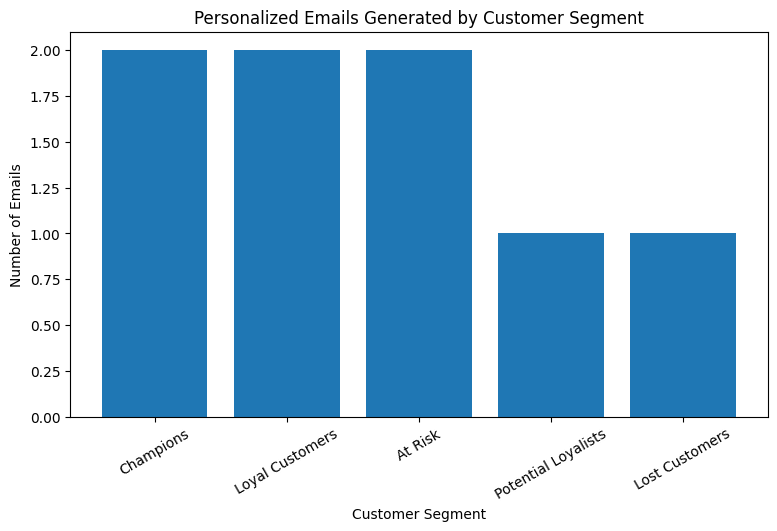

In [17]:
import matplotlib.pyplot as plt

segment_email_count = df["Segment"].value_counts()

plt.figure(figsize=(9, 5))
plt.bar(segment_email_count.index, segment_email_count.values)

plt.xlabel("Customer Segment")
plt.ylabel("Number of Emails")
plt.title("Personalized Emails Generated by Customer Segment")
plt.xticks(rotation=30)

plt.show()

In [18]:
# Verify that each generated email matches the customer's segment

def check_segment_consistency(row):
    segment = row["Segment"]
    offer = row["Promotion"]
    email = row["Generated_Email"]

    if offer.lower() in email.lower():
        return "Consistent"
    else:
        return "Not Consistent"

df["Consistency"] = df.apply(check_segment_consistency, axis=1)

print("SEGMENT-TO-EMAIL CONSISTENCY CHECK")
print("=" * 50)

display(
    df[
        [
            "CustomerName",
            "Segment",
            "Promotion",
            "Consistency"
        ]
    ]
)

SEGMENT-TO-EMAIL CONSISTENCY CHECK


,CustomerName,Segment,Promotion,Consistency
0,Priya,Champions,20% discount,Consistent
1,Arun,Loyal Customers,15% discount,Consistent
2,Kavi,Potential Loyalists,10% discount,Consistent
3,Dharshini,At Risk,25% discount,Consistent
4,Nithya,Champions,20% discount,Consistent
5,Selva,Lost Customers,30% discount,Consistent
6,Jeya,Loyal Customers,15% discount,Consistent
7,Krishna,At Risk,25% discount,Consistent


In [19]:
# Calculate final evaluation results

total = len(df)
personalized = (df["Personalized"] == "Yes").sum()
consistent = (df["Consistency"] == "Consistent").sum()

print("=" * 55)
print("FINAL EMAIL GENERATION EVALUATION")
print("=" * 55)

print("Total Customers        :", total)
print("Personalized Emails    :", personalized)
print("Consistent Emails      :", consistent)

print("\nPersonalization Rate   :", round((personalized / total) * 100, 2), "%")
print("Consistency Rate       :", round((consistent / total) * 100, 2), "%")

if personalized == total and consistent == total:
    print("\nStatus: All emails are personalized and consistent.")
else:
    print("\nStatus: Some emails require further checking.")

FINAL EMAIL GENERATION EVALUATION
Total Customers        : 8
Personalized Emails    : 8
Consistent Emails      : 8

Personalization Rate   : 100.0 %
Consistency Rate       : 100.0 %

Status: All emails are personalized and consistent.


In [20]:
# Save the complete email generation results

final_file = "Customer_Segment_LLM_Email_Results.csv"

df.to_csv(final_file, index=False)

print("Final results saved successfully!")
print("File name:", final_file)

Final results saved successfully!
File name: Customer_Segment_LLM_Email_Results.csv


In [21]:
from google.colab import files

files.download("Customer_Segment_LLM_Email_Results.csv")

print("Download started successfully!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started successfully!


In [22]:
print("=" * 60)
print("FINAL RESULT")
print("=" * 60)

print("Customer segmentation completed.")
print("CLV values calculated.")
print("Segment-specific promotions assigned.")
print("LLM prompts created.")
print("Personalized emails generated.")
print("Email personalization verified.")
print("Email consistency verified.")
print("Final results saved successfully.")

print("\nProject Status: COMPLETED")

FINAL RESULT
Customer segmentation completed.
CLV values calculated.
Segment-specific promotions assigned.
LLM prompts created.
Personalized emails generated.
Email personalization verified.
Email consistency verified.
Final results saved successfully.

Project Status: COMPLETED
